In [40]:
import os
import sys

PROJECT_NAME = 'june-2026'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Practice\PnT\june-2026


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [42]:
df = pd.read_csv("./datasets/titanic-dataset-raw.csv")
df.shape

(891, 12)

In [43]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [44]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [45]:
df.columns.to_list()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [46]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [48]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [49]:
df.isnull().sum().sum()

np.int64(866)

In [50]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [51]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [52]:
df.min(numeric_only=True)

PassengerId    1.00
Survived       0.00
Pclass         1.00
Age            0.42
SibSp          0.00
Parch          0.00
Fare           0.00
dtype: float64

In [53]:
df.max(numeric_only=True)

PassengerId    891.0000
Survived         1.0000
Pclass           3.0000
Age             80.0000
SibSp            8.0000
Parch            6.0000
Fare           512.3292
dtype: float64

In [54]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [55]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode().iloc[0])
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [56]:
df = df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])
df.dtypes

Survived      int64
Pclass        int64
Sex             str
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked        str
dtype: object

In [57]:
df["Embarked"] = df["Embarked"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["SibSp"] = df["SibSp"].astype("int8")
df["Parch"] = df["Parch"].astype("int8")
df.dtypes

Survived       int64
Pclass      category
Sex         category
Age          float64
SibSp           int8
Parch           int8
Fare         float64
Embarked    category
dtype: object

In [58]:
numeric_columns = df.select_dtypes(include=np.number).columns
stat_table = pd.DataFrame()

stat_table["Mean"] = df[numeric_columns].mean()
stat_table["Median"] = df[numeric_columns].median()
stat_table["Mode"] = df[numeric_columns].mode().iloc[0]
stat_table["Variance"] = df[numeric_columns].var()
stat_table["STD"] = df[numeric_columns].std()
stat_table["Min"] = df[numeric_columns].min()
stat_table["Max"] = df[numeric_columns].max()
stat_table["Q1"] = df[numeric_columns].quantile(.25)
stat_table["Q3"] = df[numeric_columns].quantile(.75)
stat_table["IQR"] = stat_table["Q3"] - stat_table["Q1"]
stat_table["Lower Bound"] = stat_table["Q1"] - (1.5* stat_table["IQR"])
stat_table["Upper Bound"] = stat_table["Q3"] + (1.5 * stat_table["IQR"])
stat_table

,Mean,Median,Mode,Variance,STD,Min,Max,Q1,Q3,IQR,Lower Bound,Upper Bound
Survived,0.383838,0.0000,0.00,0.236772,0.486592,0.00,1.0000,0.0000,1.0,1.0000,-1.500,2.5000
Age,29.361582,28.0000,28.00,169.512498,13.019697,0.42,80.0000,22.0000,35.0,13.0000,2.500,54.5000
SibSp,0.523008,0.0000,0.00,1.216043,1.102743,0.00,8.0000,0.0000,1.0,1.0000,-1.500,2.5000
Parch,0.381594,0.0000,0.00,0.649728,0.806057,0.00,6.0000,0.0000,0.0,0.0000,0.000,0.0000
Fare,32.204208,14.4542,8.05,2469.436846,49.693429,0.00,512.3292,7.9104,31.0,23.0896,-26.724,65.6344


*CLI*

In [ ]:
sample = df["Age"].sample(n=30, random_state=42)
sample_mean = sample.mean()
population_mean = df["Age"].mean()

print(f"Population mean: {population_mean:.2f}")
print(f"Sample mean: {sample_mean:.2f}")


print("The sample mean should be close to the population mean")

Population mean: 29.36
Sample mean: 26.00
The population mean should be close to the sample mean


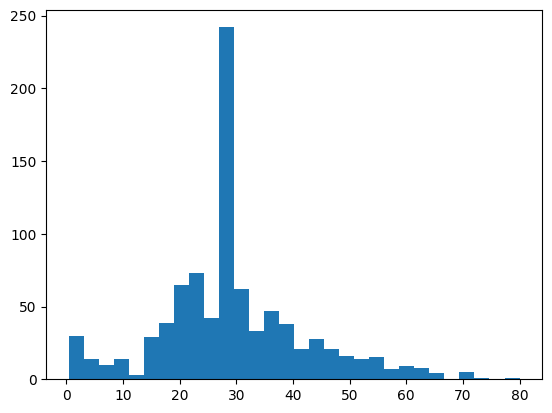

In [60]:
plt.hist(df["Age"], bins=30)
plt.show()

In [61]:
sample_mean = []

for i in range(1000):
    sample = df["Age"].sample(n=30, replace=True)
    sample_mean.append(sample.mean())

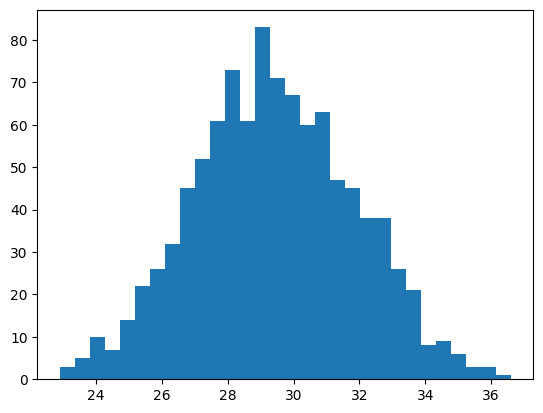

In [62]:
plt.hist(sample_mean, bins=30)
plt.show()

In [63]:
print(f"Population means: {df['Age'].mean():.2f}")
sample_mean = np.array(sample_mean)
mean_of_sample_mean = sample_mean.mean()
print(f"Sample mean: {mean_of_sample_mean:.2f}")


Population means: 29.36
Sample mean: 29.40


*Covariance*

In [64]:
x = df["Age"]
y = df["Fare"]

cov_value = x.cov(y)
print("Covariance:", cov_value)


Covariance: 62.55676722782509


*Hypothisis testing*

In [65]:
male_age = df[df["Sex"]=="male"]["Age"]
female_age = df[df["Sex"] == "female"]["Age"]

In [66]:
t_stat, p_value = stats.ttest_ind(male_age, female_age)

print(f"T-Statistic: {t_stat}")
print(f"P-value: {p_value}")


T-Statistic: 2.4279606481426024
P-value: 0.015381536989875318


In [67]:
alpha = .05

if p_value <= alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

Reject H0


*Confidence Interval*

In [68]:
fare_mean = df["Fare"].mean()
fare_std = df["Fare"].std()
n = len(df)

SE = fare_std/np.sqrt(n)

print("Standard Error:", SE)

Standard Error: 1.6647924970016779


In [69]:
"95% Confidenc Interval"

lower_95 = fare_mean - 1.96 * SE
upper_95 = fare_mean + 1.96 * SE

print("95% Interval")
print(lower_95, upper_95)

95% Interval
28.94121467445135 35.46720126269793


In [70]:
"99% Confidenc Interval"

lower_99 = fare_mean - 2.576 * SE
upper_99 = fare_mean + 2.576 * SE

print("99% Interval")
print(lower_99, upper_99)

99% Interval
27.915702496298312 36.492713440850956


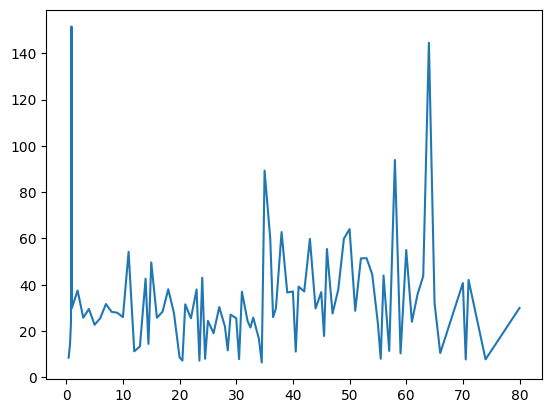

In [71]:
x = df.groupby(df["Age"])["Fare"].mean()

plt.plot(x.index, x.values)
plt.show()

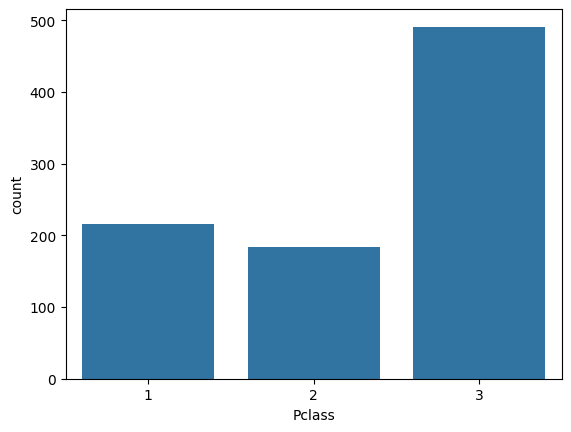

In [72]:
sns.countplot(x="Pclass", data=df)
plt.show()

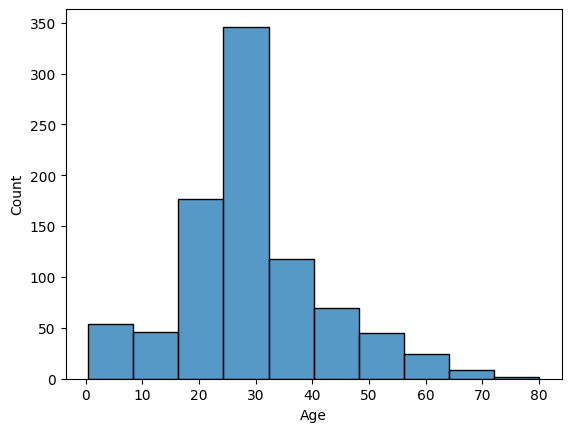

In [73]:

sns.histplot(df["Age"], bins=10)
plt.show()

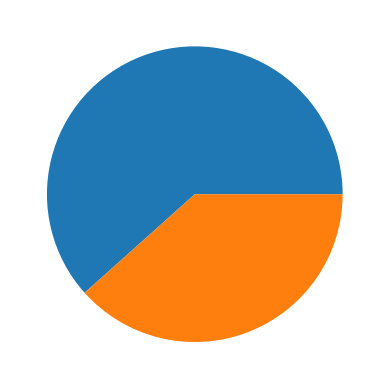

In [74]:
plt.pie(df["Survived"].value_counts())
plt.show()

<Axes: xlabel='Age'>

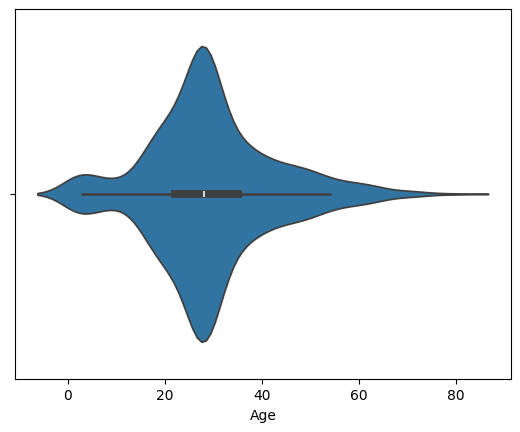

In [75]:
sns.violinplot(x="Age", data=df)

<Axes: xlabel='Age'>

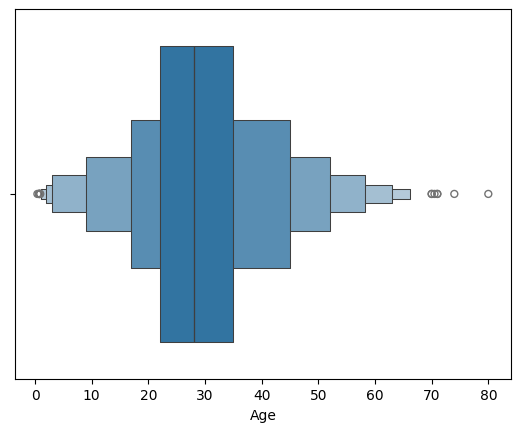

In [76]:
sns.boxenplot(x="Age", data=df)

<Axes: xlabel='Fare', ylabel='Age'>

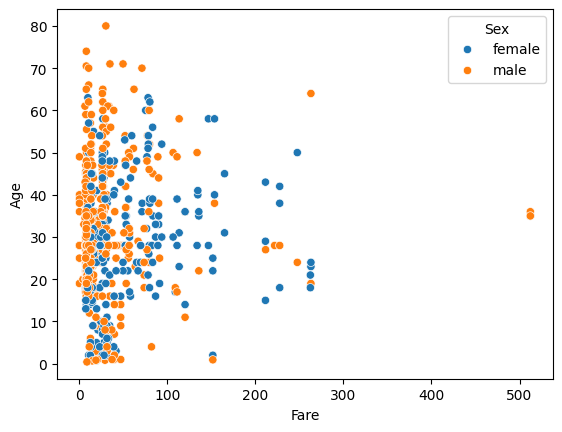

In [77]:
sns.scatterplot(x="Fare", y="Age", hue="Sex", data=df)

<Axes: >

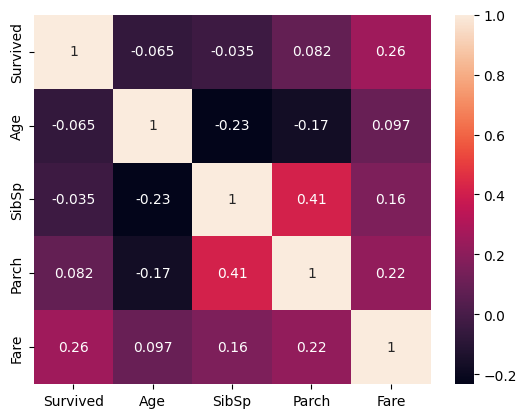

In [78]:
sns.heatmap(df[numeric_columns].corr(), annot=True)